In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url="https://github.com/14Richa/Patient-Readmission-Analysis/raw/refs/heads/main/diabetic_data.csv"

df= pd.read_csv(url)

print(df.shape)
print (df.head())

(101766, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital payer_code         medical_specialty  num_lab_procedures  \
0                 1          ?  Pediatric

In [148]:
pd.set_option('display.max_columns',None)
print (df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital payer_code         medical_specialty  num_lab_procedures  \
0                 1          ?  Pediatrics-Endocrinolo

In [149]:
print ("Data Types:")
print (df.dtypes)

print ("n/Missing Values:")
print (df.isnull().sum())

print ("n/Statisitics:")
print (df.describe())

Data Types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepir

In [150]:
df= df.drop(columns=['encounter_id', 'patient_nbr', 'weight',
                       'payer_code', 'medical_specialty',
                       'max_glu_serum', 'A1Cresult'])

df= df.replace('?',np.nan)

print("Shape after dropping columns:", df.shape)
print("\nMissing values after replacing ?:")
print(df.isnull().sum())

Shape after dropping columns: (101766, 43)

Missing values after replacing ?:
race                        2273
gender                         0
age                            0
admission_type_id              0
discharge_disposition_id       0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
num_procedures                 0
num_medications                0
number_outpatient              0
number_emergency               0
number_inpatient               0
diag_1                        21
diag_2                       358
diag_3                      1423
number_diagnoses               0
metformin                      0
repaglinide                    0
nateglinide                    0
chlorpropamide                 0
glimepiride                    0
acetohexamide                  0
glipizide                      0
glyburide                      0
tolbutamide                    0
pioglitazone                   0
rosiglitazone                  

In [151]:
df['race']= df['race'].fillna('unknown')

df= df.dropna(subset=['diag_1'])

df['diag_2']= df['diag_2'].fillna('unknown')

df['diag_3']= df['diag_3'].fillna('unknown')

print ("Missing Values Remaining:")
print (df.isnull().sum())
print ("n/Final Shape",df.shape)


Missing Values Remaining:
race                        0
gender                      0
age                         0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide                  0
examide       

In [152]:
df['readmitted']= (df['readmitted']=='<30').astype(int)

print ('Readmission Distribution:')
print (df['readmitted'].value_counts())

print('\nPercentage Readmitted Within 30 Days:')
print (round (df['readmitted'].mean() * 100 , 2), '%')

Readmission Distribution:
readmitted
0    90393
1    11352
Name: count, dtype: int64

Percentage Readmitted Within 30 Days:
11.16 %


In [153]:
age_readmission = df.groupby('age')['readmitted'].mean()*100

age_readmission = age_readmission.sort_values(ascending=False)

print ('Readmission Rate By Age Group:')

print (round(age_readmission,2))

Readmission Rate By Age Group:
age
[20-30)     14.25
[80-90)     12.08
[70-80)     11.77
[30-40)     11.23
[60-70)     11.13
[90-100)    11.10
[40-50)     10.60
[50-60)      9.67
[10-20)      5.79
[0-10)       1.86
Name: readmitted, dtype: float64


In [154]:
medication_readmission = df.groupby('readmitted')['num_medications'].mean()

print('Average Medications By Readmission Status:')

print (round(medication_readmission,2))

Average Medications By Readmission Status:
readmitted
0    15.91
1    16.90
Name: num_medications, dtype: float64


In [155]:
stay_readmission=df.groupby('readmitted')['time_in_hospital'].mean()

print ('Average Hospital Stay By Readmission Status:')

print (round(stay_readmission,2))

Average Hospital Stay By Readmission Status:
readmitted
0    4.35
1    4.77
Name: time_in_hospital, dtype: float64


In [156]:
diagnoses_readmission=df.groupby ('readmitted')['number_diagnoses'].mean()

print ('Average Diagnoses By Readmission Status:')

print(round(diagnoses_readmission,2))

Average Diagnoses By Readmission Status:
readmitted
0    7.39
1    7.69
Name: number_diagnoses, dtype: float64


In [157]:
inpatient_readmission=df.groupby('readmitted')['number_inpatient'].mean()

print ('Average Prior Inpatient Visits By Readmission Stautus:')

print(round(inpatient_readmission,2))

Average Prior Inpatient Visits By Readmission Stautus:
readmitted
0    0.56
1    1.22
Name: number_inpatient, dtype: float64


/tmp/ipykernel_3406/1877386714.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_plot.index, y=age_plot.values, palette='Blues')


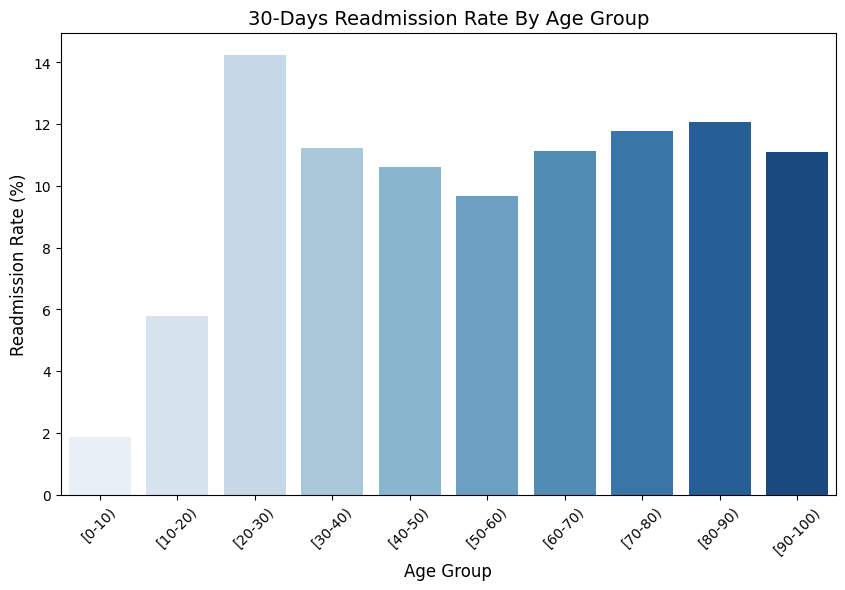

In [158]:
plt.figure(figsize=(10,6))

age_order= ['[0-10)','[10-20)','[20-30)','[30-40)','[40-50)','[50-60)','[60-70)','[70-80)','[80-90)','[90-100)']

age_plot= df.groupby('age')['readmitted'].mean()*100
age_plot= age_plot.reindex(age_order)

sns.barplot(x=age_plot.index, y=age_plot.values, palette='Blues')

plt.title('30-Days Readmission Rate By Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Readmission Rate (%)', fontsize=12)

plt.xticks(rotation=45)
plt.show()

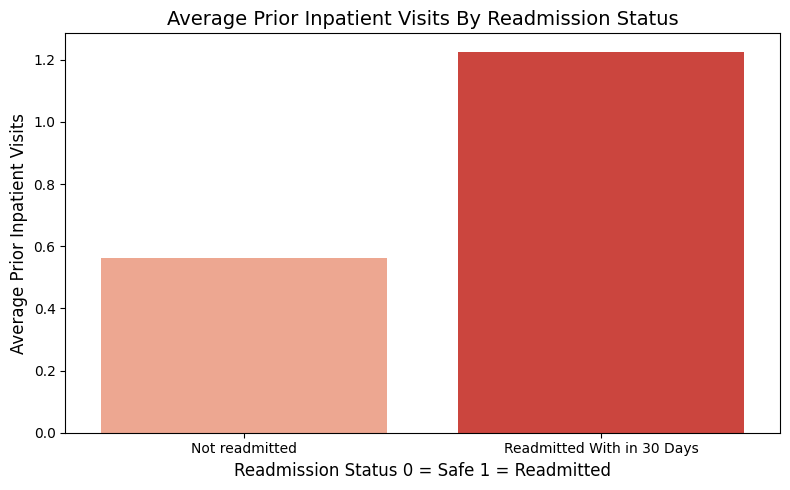

In [159]:
plt.figure(figsize=(8,5))

inpatient_plot=df.groupby('readmitted')['number_inpatient'].mean()

sns.barplot(x=inpatient_plot.index, y=inpatient_plot.values,palette='Reds', hue=inpatient_plot.index, legend=False)

plt.title('Average Prior Inpatient Visits By Readmission Status', fontsize=14)
plt.xlabel('Readmission Status 0 = Safe 1 = Readmitted', fontsize=12)
plt.ylabel('Average Prior Inpatient Visits', fontsize=12)

plt.xticks([0,1],['Not readmitted', 'Readmitted With in 30 Days'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_3406/534100953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='readmitted', y='num_medications', data=df, palette='Greens')


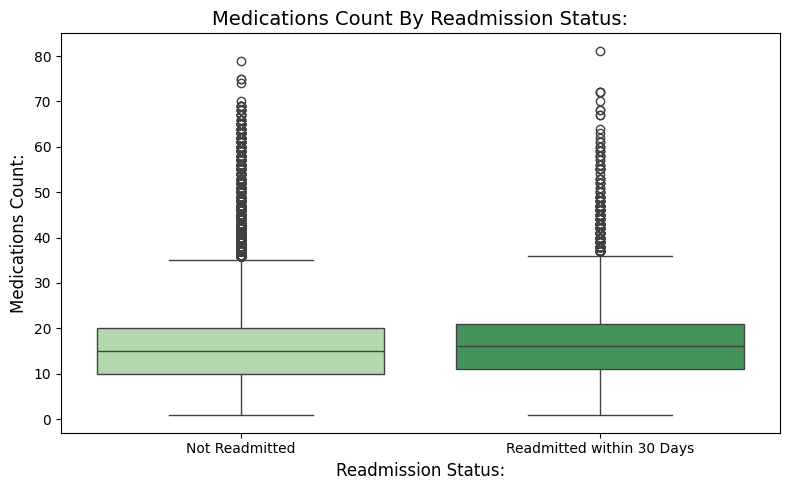

In [160]:
plt.figure(figsize=(8,5))

sns.boxplot(x='readmitted', y='num_medications', data=df, palette='Greens')

plt.title('Medications Count By Readmission Status:', fontsize=14)
plt.xlabel('Readmission Status:', fontsize=12)
plt.ylabel('Medications Count:', fontsize=12)
plt.xticks([0,1],['Not Readmitted','Readmitted within 30 Days'])

plt.tight_layout()
plt.show()

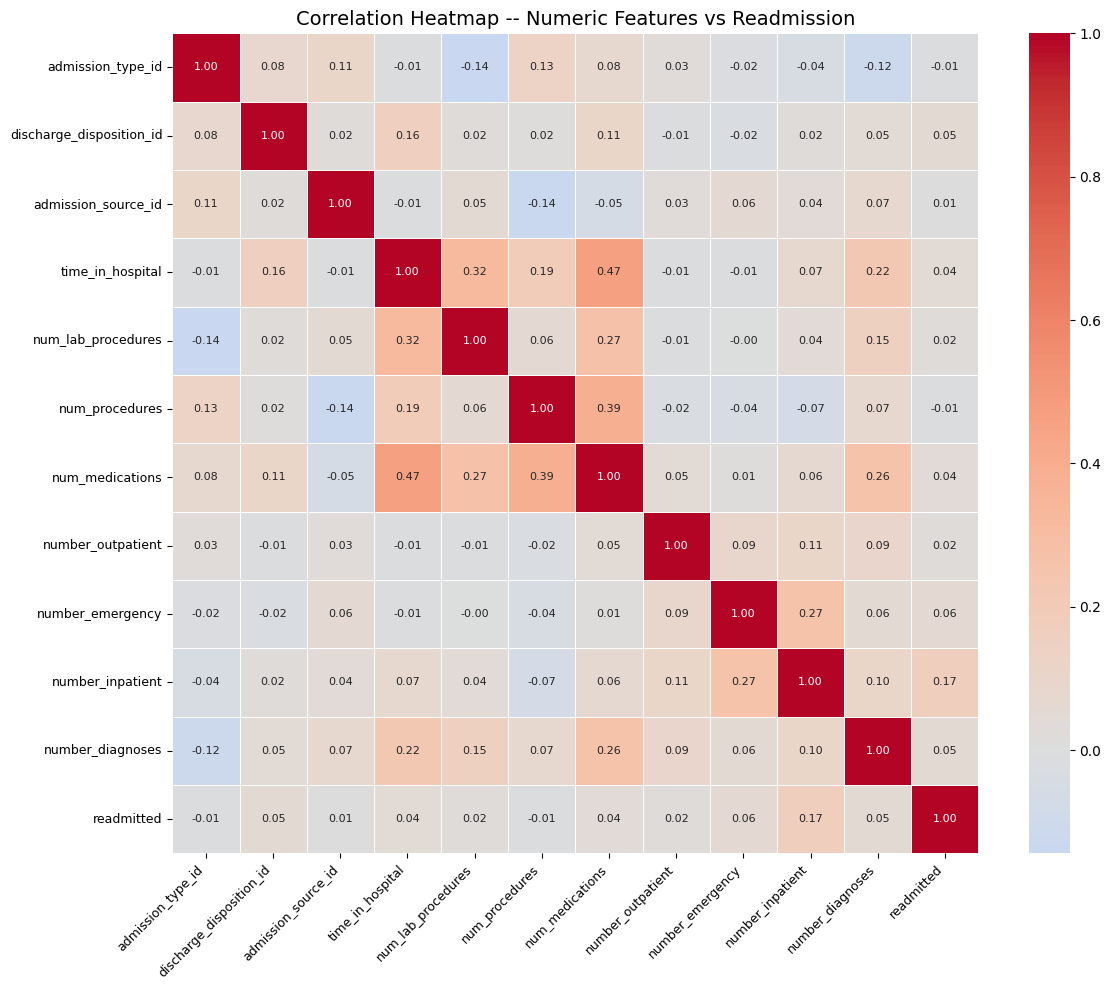

In [161]:
plt.figure(figsize=(12,10))

numeric_df= df.select_dtypes(include=['int64','float64'])

correlation= numeric_df.corr()

sns.heatmap(correlation,annot=True,fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'fontsize':8})

plt.title('Correlation Heatmap -- Numeric Features vs Readmission', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

In [162]:
from sklearn.preprocessing import LabelEncoder

df_model=df.copy()

le= LabelEncoder()

text_columns= df_model.select_dtypes(include=['object']).columns

for col in text_columns: df_model[col]=le.fit_transform(df_model[col])

print ('Shape After Encoding:', df_model.shape)
print('\n Data Types After Encoding:')
print (df_model.dtypes)

Shape After Encoding: (101745, 43)

 Data Types After Encoding:
race                        int64
gender                      int64
age                         int64
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                      int64
diag_2                      int64
diag_3                      int64
number_diagnoses            int64
metformin                   int64
repaglinide                 int64
nateglinide                 int64
chlorpropamide              int64
glimepiride                 int64
acetohexamide               int64
glipizide                   int64
glyburide                   int64
tolbutamide                 int64
pioglitazone                int64
rosiglitazone     

In [163]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

X = df_model.drop(columns=['readmitted'])
y = df_model['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.6699100692908743

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     18066
           1       0.17      0.51      0.26      2283

    accuracy                           0.67     20349
   macro avg       0.54      0.60      0.52     20349
weighted avg       0.83      0.67      0.73     20349

